# **Dataset API Prototype**

In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt


2026-06-01 16:32:14.407897: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## WM_811K Dataset Class

In [2]:
from datasets import WM_811K
wm811k = WM_811K(imsize=(64,64))

reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

## Single Defect Tensorflow Dataset

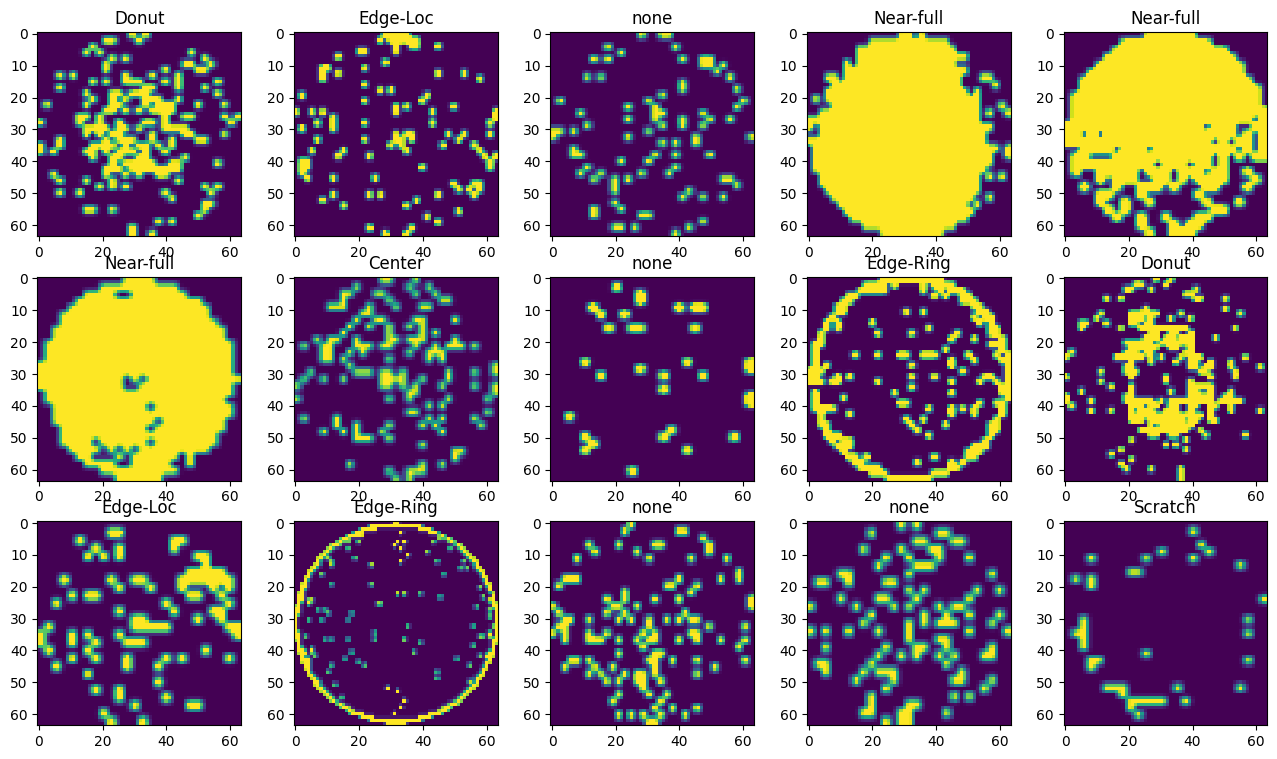

In [3]:
N_VIEW = 15
cols = min(N_VIEW, 5)
rows = (N_VIEW + cols - 1) // cols

_,axs = plt.subplots(rows,cols, figsize=(16,9))

ds = wm811k.dataset_single_defect()
for ax, (img, label) in zip(axs.flatten(), ds.take(N_VIEW)):
    ax.imshow(img)
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    ax.set_title(WM_811K.defect_from_int[i])
    

none


2026-06-01 16:59:14.370794: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


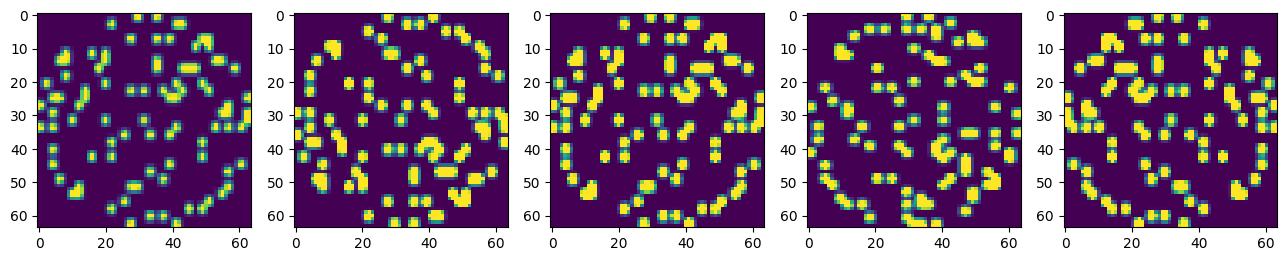

In [4]:
for img, label in ds.take(1):
    _, axs = plt.subplots(1,5, figsize=(16,4))
    axs[0].imshow(img)
    axs[1].imshow(wm811k.augment_image(img))
    axs[2].imshow(wm811k.augment_image(img))
    axs[3].imshow(wm811k.augment_image(img))
    axs[4].imshow(wm811k.augment_image(img))
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    print(WM_811K.defect_from_int[i])

## Multi Defect Tensorflow Dataset

2026-06-01 16:59:20.198509: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


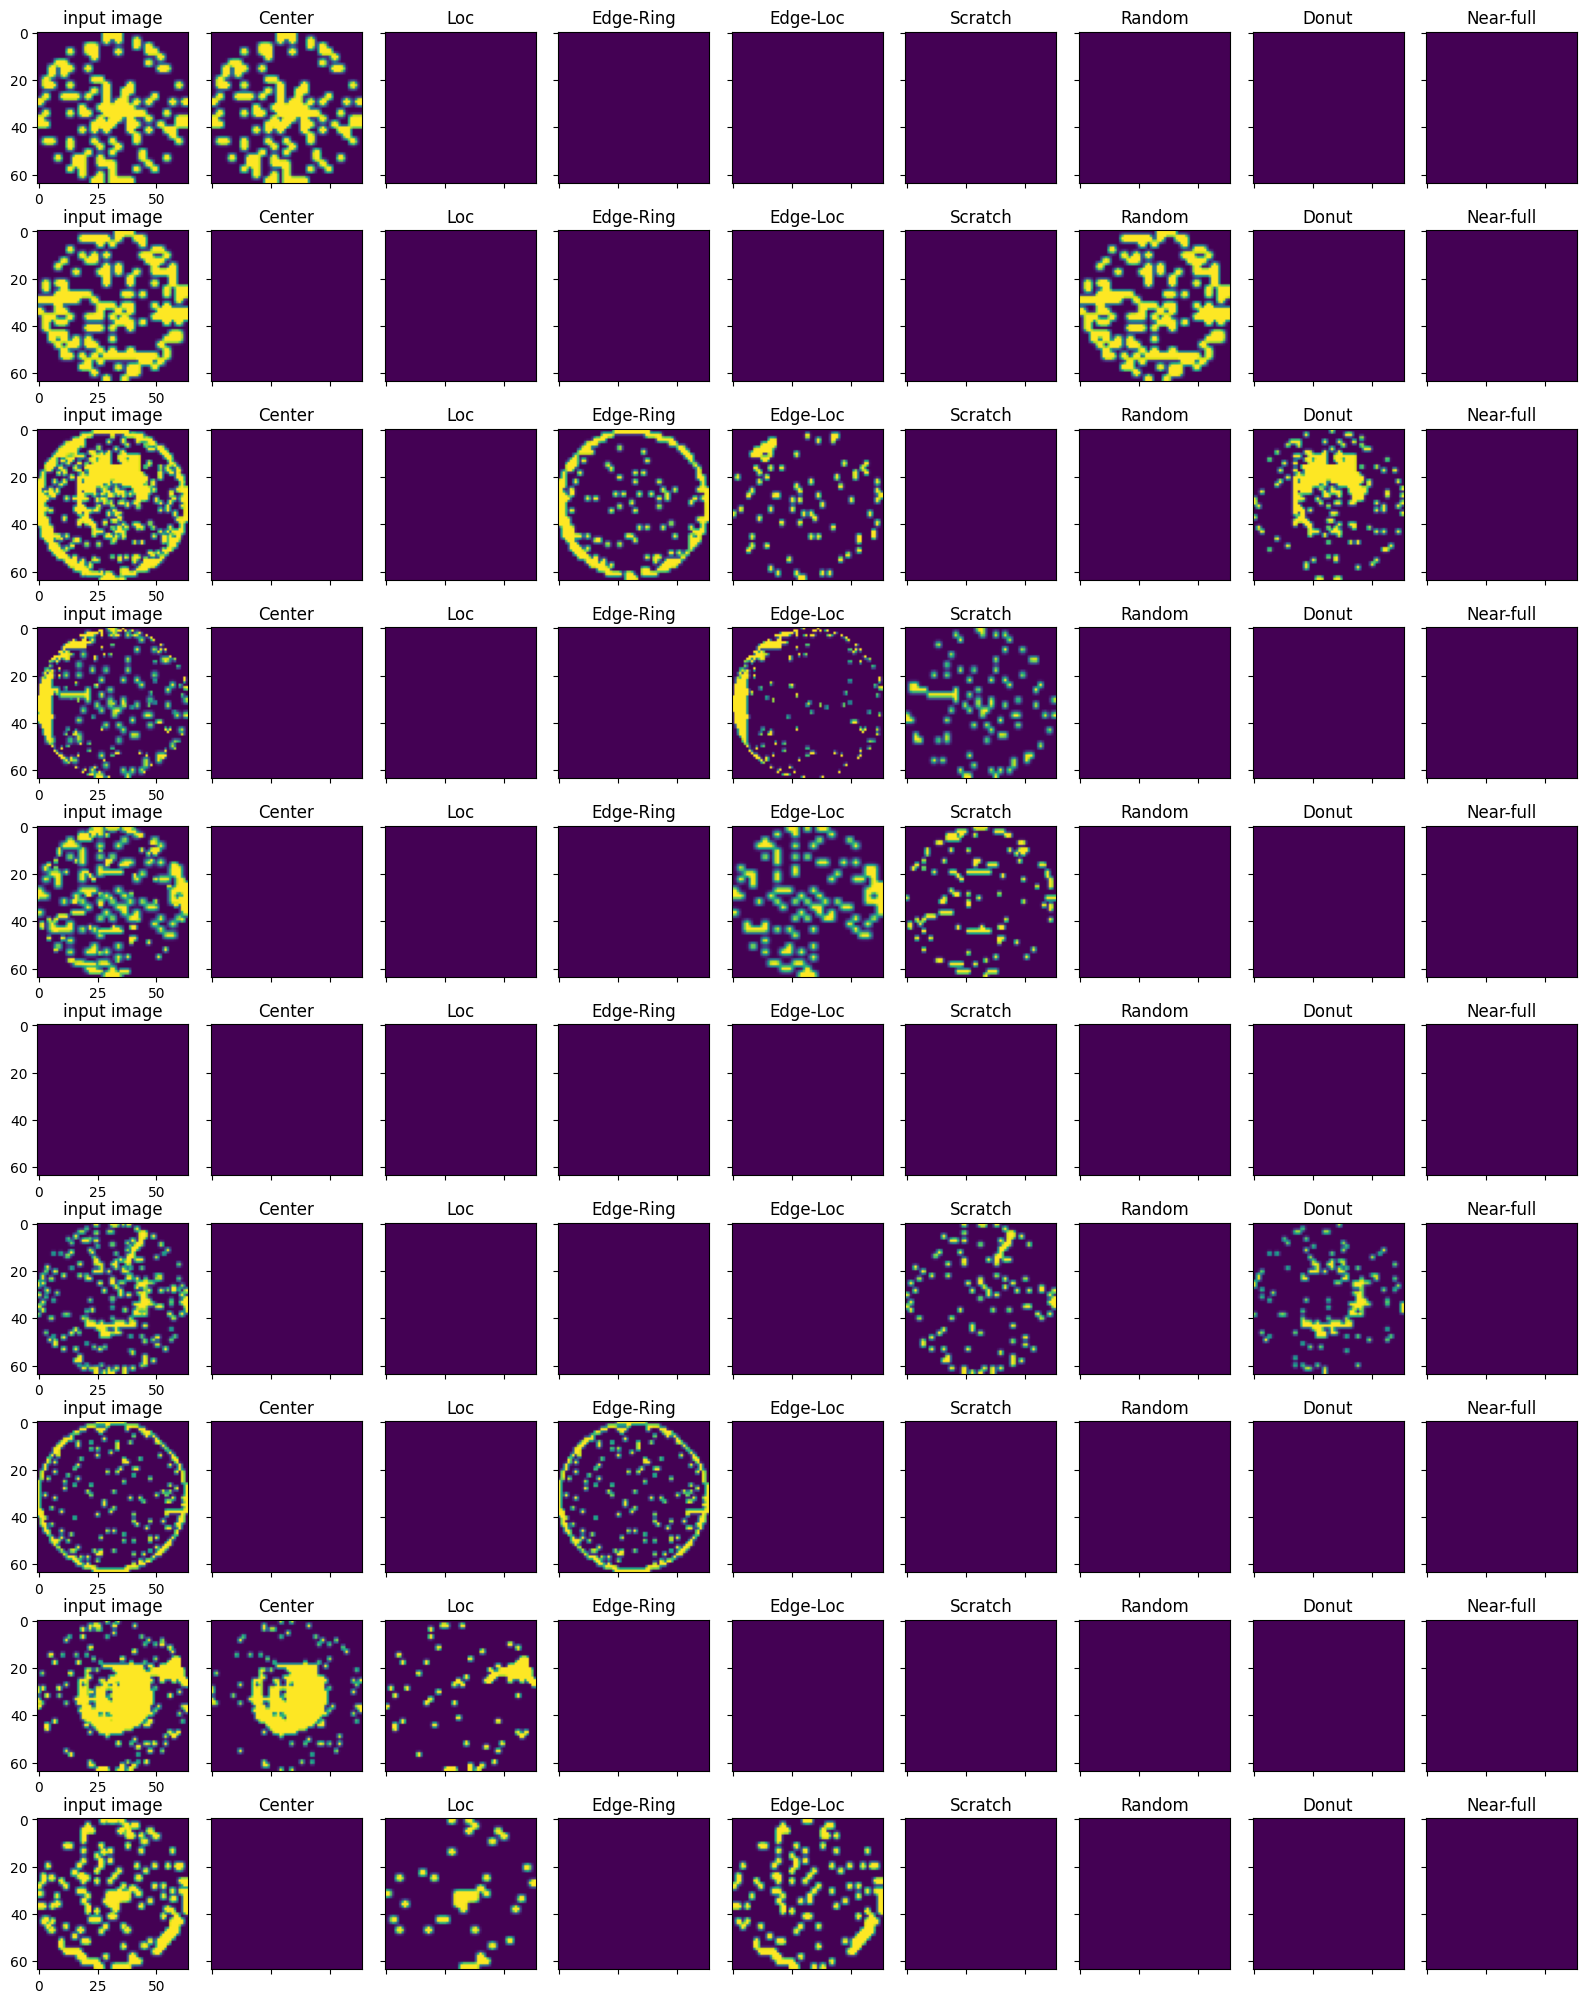

In [5]:
N_VIEW = 10
_,axs = plt.subplots(N_VIEW, 9, figsize=(16, 2*N_VIEW))

ds = wm811k.dataset_multi_defect_segmentation()
for row, (input_img, mid_stack) in enumerate(ds.take(N_VIEW)):
    axs[row,0].imshow(input_img)
    axs[row,0].set_title('input image')
    for col in range(8):
        axs[row,col+1].imshow(mid_stack[:,:,col])
        axs[row,col+1].set_title(WM_811K.defect_from_int[col])
        axs[row,col+1].set_xticklabels([])
        axs[row,col+1].set_yticklabels([])

plt.tight_layout()

## 1. Train Segmentation Model

In [6]:
model_segmentation = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(shape=(*wm811k.imsize, 1)),

    # convolution block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.25),

    # convolution block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Dropout(0.25),

    # transposed convolution block 1
    tf.keras.layers.Conv2DTranspose(64, (3, 3), activation='relu', strides=2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # transposed convolution block 2
    tf.keras.layers.Conv2DTranspose(32, (3, 3), activation='relu', strides=2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # transposed convolution block 3
    tf.keras.layers.Conv2DTranspose(8, (2, 2), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
])

model_segmentation.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

model_segmentation.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 31, 31, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 63, 63, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 8)      │         1,032 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,040 (297.03 KB)

 Trainable params: 75,640 (295.47 KB)

 Non-trainable params: 400 (1.56 KB)

In [7]:
model_segmentation = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_segmentation.keras'))

In [8]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_segmentation.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_segmentation().batch(16)
ds_validation = wm811k.dataset_multi_defect_segmentation().batch(16)

history = model_segmentation.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - loss: 0.0279
Epoch 1: val_loss improved from None to 0.02513, saving model to ../models/multi_defect_segmentation.keras

Epoch 1: finished saving model to ../models/multi_defect_segmentation.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 94s 712ms/step - loss: 0.0278 - val_loss: 0.0251
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - loss: 0.0276
Epoch 2: val_loss improved from 0.02513 to 0.02355, saving model to ../models/multi_defect_segmentation.keras

Epoch 2: finished saving model to ../models/multi_defect_segmentation.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 85s 664ms/step - loss: 0.0275 - val_loss: 0.0236
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - loss: 0.0284
Epoch 3: val_loss did not improve from 0.02355
128/128 ━━━━━━━━━━━━━━━━━━━━ 91s 714ms/step - loss: 0.0283 - val_loss: 0.0242
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - loss: 0.0289
Epoch 4: val_loss did not improve from 0.02355
128/128 ━━━━━━━━━━━━━━━━━

In [9]:
sample = list(ds_train.take(1))
pred = model_segmentation.predict(sample)

2026-06-01 18:23:29.418706: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/david/Documents/GitHub/NTU_Data_Analysis/env/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_11
Received: inputs=(('Tensor(shape=(16, 64, 64, 1))', 'Tensor(shape=(16, 64, 64, 8))'),)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step


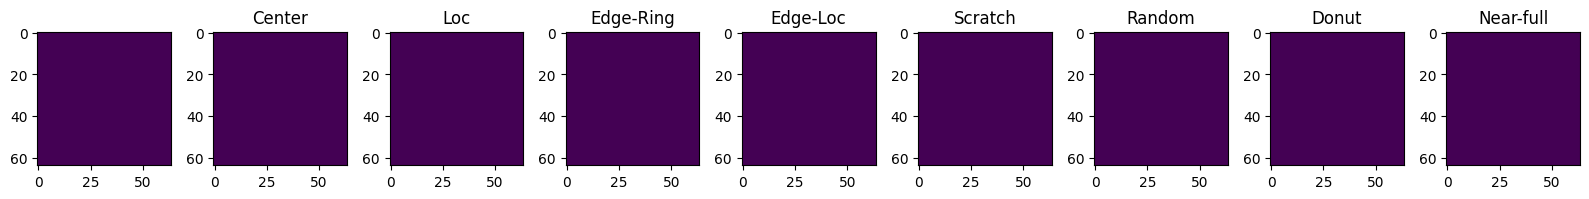

In [15]:
idx = 4
input_img, img_stack = sample[0]
_,axs = plt.subplots(1,9, figsize=(16,3))
axs[0].imshow(input_img[idx,:,:,0])
for c in range(8):
    axs[c+1].imshow(img_stack[idx,:,:,c])
    axs[c+1].set_title(WM_811K.defect_from_int[c])
plt.tight_layout()

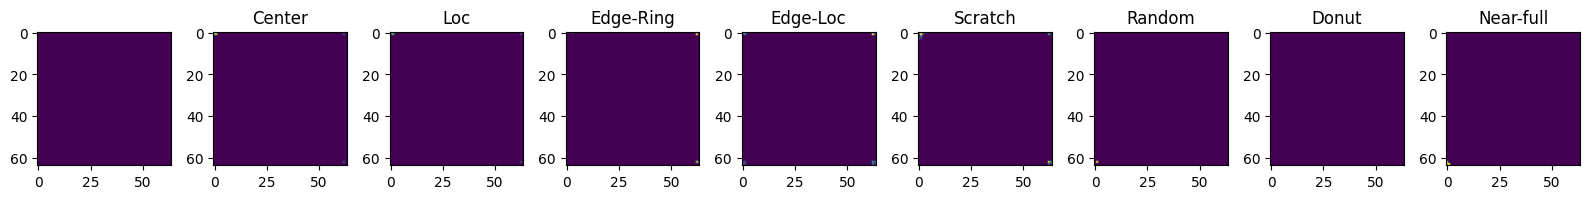

In [12]:
_,axs = plt.subplots(1,9, figsize=(16,3))
axs[0].imshow(input_img[idx,:,:,0])
for c in range(8):
    axs[c+1].imshow(pred[idx,:,:,c])
    axs[c+1].set_title(WM_811K.defect_from_int[c])
plt.tight_layout()

## 2. Train Classification Model

In [20]:
model_classification = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(*wm811k.imsize,WM_811K.n_classes-1)),
                          
    # ---- Conv block 1 -------------------------------------------------
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 2 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 3 -------------------------------------------------
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Flatten + Dense -----------------------------------------------
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='sigmoid')
    ])

model_classification.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
)

model_classification.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 62, 62, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,726,248 (10.40 MB)

 Trainable params: 2,723,752 (10.39 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [14]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_classification.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_classification().batch(16)
ds_validation = wm811k.dataset_multi_defect_classification().batch(16)

history = model_classification.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - loss: 4.6335
Epoch 1: val_loss improved from None to 4.13013, saving model to ../models/multi_defect_classification.keras

Epoch 1: finished saving model to ../models/multi_defect_classification.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 76s 555ms/step - loss: 4.1014 - val_loss: 4.1301
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - loss: 3.3951
Epoch 2: val_loss did not improve from 4.13013
128/128 ━━━━━━━━━━━━━━━━━━━━ 71s 556ms/step - loss: 3.3662 - val_loss: 5.3836
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - loss: 3.3263
Epoch 3: val_loss did not improve from 4.13013
128/128 ━━━━━━━━━━━━━━━━━━━━ 72s 565ms/step - loss: 3.3188 - val_loss: 4.3792
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - loss: 3.3308
Epoch 4: val_loss improved from 4.13013 to 3.63316, saving model to ../models/multi_defect_classification.keras

Epoch 4: finished saving model to ../models/multi_defect_classification.keras
128/128 ━━━━━━━━━

## 3. Train Combined Full Stack Model

In [29]:
model_fullstack = tf.keras.models.Sequential([
    model_segmentation,
    model_classification    
])

model_fullstack.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"]
)

model_fullstack.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 64, 64, 8)      │        76,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 8)              │     2,726,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,802,288 (10.69 MB)

 Trainable params: 2,799,392 (10.68 MB)

 Non-trainable params: 2,896 (11.31 KB)

In [30]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_fullstack().batch(16)
ds_validation = wm811k.dataset_multi_defect_fullstack().batch(16)

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


Exception ignored in: <function AtomicFunction.__del__ at 0x1247a89a0>
Traceback (most recent call last):
  File "/Users/david/Documents/GitHub/NTU_Data_Analysis/env/lib/python3.11/site-packages/tensorflow/python/eager/polymorphic_function/atomic_function.py", line 286, in __del__
    def __del__(self):
  
KeyboardInterrupt: 


128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.4110 - loss: 4.4175
Epoch 1: val_loss improved from None to 3.19841, saving model to ../models/multi_defect_fullstack.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 108s 745ms/step - accuracy: 0.4102 - loss: 4.4546 - val_accuracy: 0.4004 - val_loss: 3.1984
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.3908 - loss: 4.5938
Epoch 2: val_loss improved from 3.19841 to 3.18548, saving model to ../models/multi_defect_fullstack.keras

Epoch 2: finished saving model to ../models/multi_defect_fullstack.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 722ms/step - accuracy: 0.4014 - loss: 4.5272 - val_accuracy: 0.4238 - val_loss: 3.1855
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.4223 - loss: 4.6142
Epoch 3: val_loss improved from 3.18548 to 2.92980, saving model to ../models/multi_defect_fullstack.keras

Epoch 3: finished saving model to ../mo

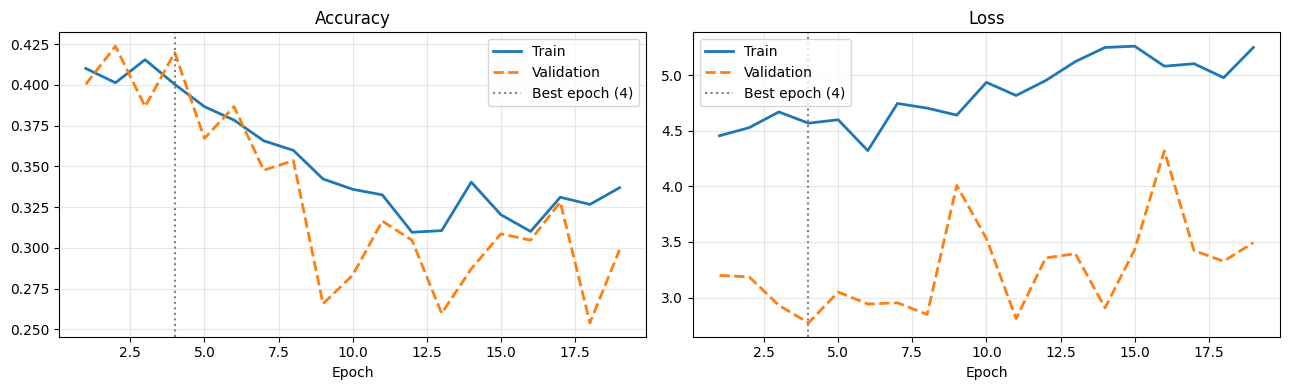

Saved ./performance_plots/training_curves.png


In [32]:
def plot_training_curves(history_dict, out_path):
    epochs  = range(1, len(history_dict["loss"]) + 1)
    best_ep = history_dict["best_epoch"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in [(ax1, "accuracy"), (ax2, "loss")]:
        ax.plot(epochs, history_dict[metric],          label="Train",      linewidth=2)
        ax.plot(epochs, history_dict[f"val_{metric}"], label="Validation", linewidth=2, linestyle="--")
        ax.axvline(best_ep, color="gray", linestyle=":", label=f"Best epoch ({best_ep})")
        ax.set_title(metric.capitalize()); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()
    print(f"Saved {out_path}")

history_dict = dict(history.history)
history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
history_dict["best_epoch"]        = int(np.argmin(history.history["val_loss"])) + 1
history_dict["best_val_accuracy"] = float(min(history.history["val_loss"]))

OUTPUT_DIR   = "./performance_plots"   # all performance plots written here

plot_training_curves(history_dict, out_path=os.path.join(OUTPUT_DIR, "training_curves.png"))